<a href="https://colab.research.google.com/github/jesusessu/MDD_LAB13/blob/develop/MDD_S13.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**SEMANA 13: AJUSTE DE HIPERPARÁMETROS DE UN MODELO. ESTRATEGIAS DE COMPARACIÓN Y EVALUACIÓN DE DIFERENTES MODELOS**

**Alumno:** Esplana Sulla Jesús Zósimo

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score
from sklearn.pipeline import Pipeline

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

In [3]:
# Cargar datos
url = "/content/drive/MyDrive/TECSUP/Ciclo 5/Mineria de Datos/garments_worker_productivity.csv"
df = pd.read_csv(url)

# Eliminar la variable 'date' y crear variable binaria 'productivity_level'
df.drop('date', axis=1, inplace=True)
df['productivity_level'] = np.where(df['actual_productivity'] >= 0.5, 1, 0)
df.drop('actual_productivity', axis=1, inplace=True)

df.head()

,quarter,department,day,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,productivity_level
0,Quarter1,sweing,Thursday,8,0.80,26.16,1108.0,7080,98,0.0,0,0,59.0,1
1,Quarter1,finishing,Thursday,1,0.75,3.94,NaN,960,0,0.0,0,0,8.0,1
2,Quarter1,sweing,Thursday,11,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,1
3,Quarter1,sweing,Thursday,12,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,1
4,Quarter1,sweing,Thursday,6,0.80,25.90,1170.0,1920,50,0.0,0,0,56.0,1


quarter                    0
department                 0
day                        0
team                       0
targeted_productivity      0
smv                        0
wip                      506
over_time                  0
incentive                  0
idle_time                  0
idle_men                   0
no_of_style_change         0
no_of_workers              0
productivity_level         0
dtype: int64


<ipython-input-4-2915554014>:5: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


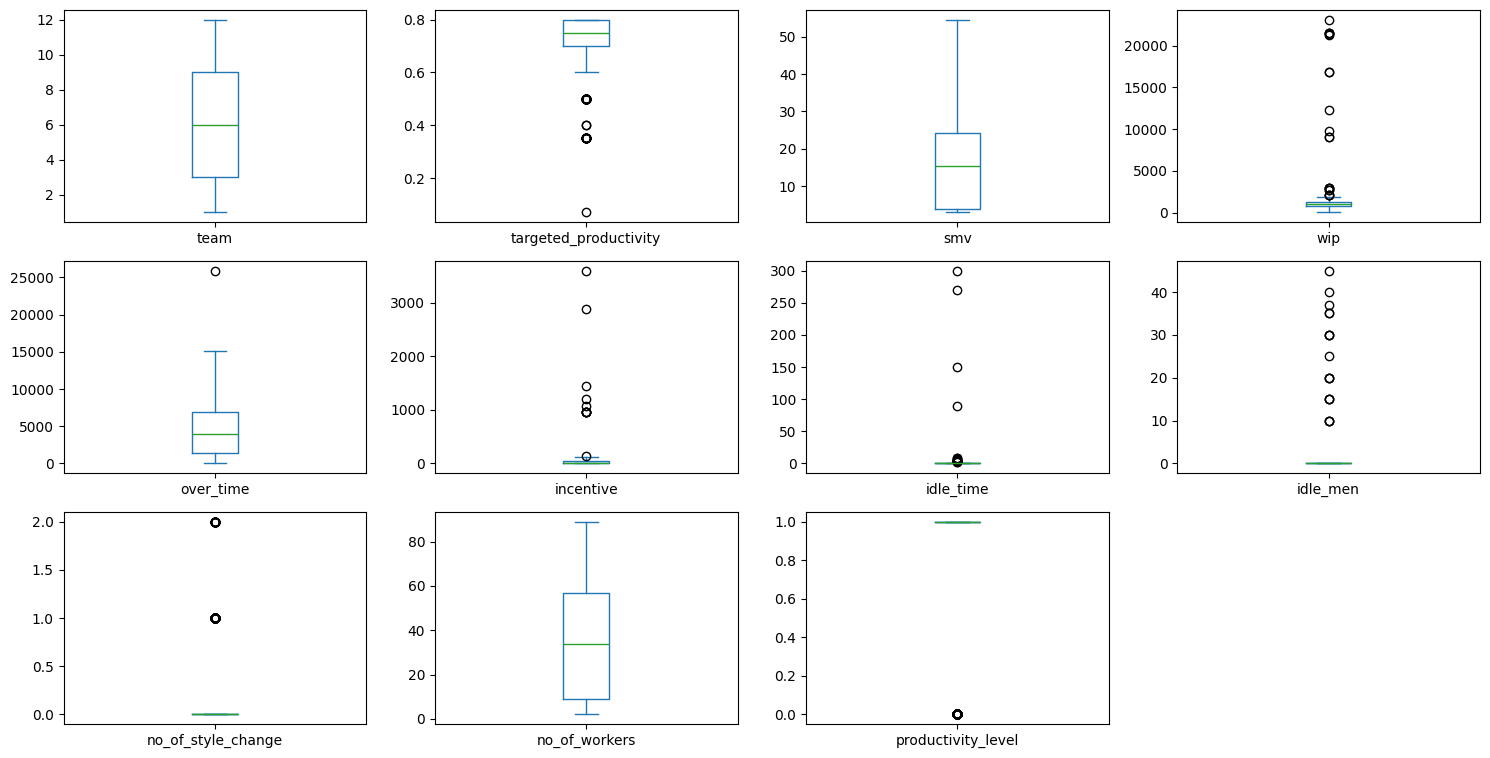

In [4]:
# Datos faltantes
print(df.isnull().sum())

# Imputar si es necesario
df.fillna(method='ffill', inplace=True)

# Outliers univariados
df.describe()

# Boxplots
numeric_cols = df.select_dtypes(include=np.number).columns
df[numeric_cols].plot(kind='box', subplots=True, layout=(4,4), figsize=(15,10), sharex=False)
plt.tight_layout()
plt.show()

In [5]:
# Dummificar y escalar
df = pd.get_dummies(df, drop_first=True)
X = df.drop("productivity_level", axis=1)
y = df["productivity_level"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [7]:
models = {
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(),
    "LogReg": LogisticRegression(max_iter=1000),
    "Tree": DecisionTreeClassifier(),
    "RF": RandomForestClassifier(),
    "NB": GaussianNB()
}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    print(f"\n{name} Accuracy:", accuracy_score(y_test, preds))


KNN Accuracy: 0.8916666666666667

SVM Accuracy: 0.9083333333333333

LogReg Accuracy: 0.8875

Tree Accuracy: 0.875

RF Accuracy: 0.9208333333333333

NB Accuracy: 0.8708333333333333


In [8]:
param_grid = {
    'n_estimators': [10, 50, 100],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5],
}

grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=3, scoring='accuracy')
grid.fit(X_train, y_train)

print("Best params (GridSearch):", grid.best_params_)
print("Best accuracy (GridSearch):", grid.best_score_)

Best params (GridSearch): {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 10}
Best accuracy (GridSearch): 0.910135841170324


In [9]:
from scipy.stats import randint

param_dist = {
    'n_estimators': randint(10, 200),
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': randint(2, 10)
}

rand_search = RandomizedSearchCV(RandomForestClassifier(), param_distributions=param_dist, n_iter=10, cv=3, scoring='accuracy', random_state=42)
rand_search.fit(X_train, y_train)

print("Best params (RandomSearch):", rand_search.best_params_)
print("Best accuracy (RandomSearch):", rand_search.best_score_)

Best params (RandomSearch): {'max_depth': 10, 'min_samples_split': 4, 'n_estimators': 81}
Best accuracy (RandomSearch): 0.8996865203761756


In [10]:
best_model = rand_search.best_estimator_
y_pred = best_model.predict(X_test)
print("Final Model Report:\n", classification_report(y_test, y_pred))

Final Model Report:
               precision    recall  f1-score   support

           0       0.78      0.32      0.45        22
           1       0.94      0.99      0.96       218

    accuracy                           0.93       240
   macro avg       0.86      0.65      0.71       240
weighted avg       0.92      0.93      0.92       240

